# Figure Studio — Module 1 Concept Figures

This notebook **regenerates every figure** used in
`guide01_concepts_logistic-regression-and-classification-metrics.md`.

The figures in the reading guide are not decorations — each one is built from the *same* worked numbers used in the guide's text, so the plots and the prose
always agree. Keeping them here as editable cells means you can tweak a title, a colour, an annotation, or the underlying numbers, re-run one cell, and the guide's image updates in place.

**How it is organised.**
- Run the **Setup** cell once. It imports the libraries, sets the shared plotting style, creates the `figures/` folder, and defines two tiny helpers (`sig`, `ols`) and the colour palette used throughout.
- After that, each figure has its **own pair of cells**: a short markdown note explaining what the figure teaches and where it appears in the guide, followed by a self-contained code cell. Every code cell reseeds its own random generator, so you can run them **in any order**.

**How to use it.**
1. Run **Setup**.
2. Run any figure cell. It will *display the figure inline* **and** *save the PNG* into `figures/`.
3. To change a figure, edit the title / annotation / numbers in its code cell and re-run — then refresh the guide to see the new image.

> **Tip for editing text on a figure.** In each code cell, the human-readable strings live in
> `ax.set_title(...)`, `ax.set_xlabel(...)`, `ax.annotate(...)`, and `ax.text(...)`. Those are the
> lines to change when you want to reword what a figure says.

**Requirements:** `numpy`, `matplotlib`, `scikit-learn` (all standard; already present in Colab/Anaconda).


## Setup — run this first

In [ ]:
#Uncomment the following line and run this cell if you need to install the modules
#!pip install numpy matplotlib scikit-learn

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)

# Shared plotting style so every figure looks consistent
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.bbox": "tight",
})

# Where the PNGs are written (same folder the guide links to)
OUT = "figures/"
os.makedirs(OUT, exist_ok=True)

# Shared colour palette
C0, C1 = "#3b76af", "#d1495b"                      # blue = class 0 / negative, red = class 1 / positive
RED, BLUE, PUR, GRN = "#d1495b", "#3b76af", "#7b2d8e", "#2a7d4f"   # used by the Section-16 scenario map

# Two tiny helpers reused by several figures
def sig(z):
    """The sigmoid / logistic function."""
    return 1 / (1 + np.exp(-z))

def ols(x, y):
    """Fit a simple ordinary-least-squares line; returns (intercept, slope)."""
    b1 = np.cov(x, y, bias=True)[0, 1] / np.var(x)
    return y.mean() - b1 * x.mean(), b1

print("Setup complete. Figures will be saved to:", os.path.abspath(OUT))

Setup complete. Figures will be saved to: /Users/souvikmandal/Documents/S01_Learning/IBM_Machine-Learning-Professional-Certificate/course03_Supervised-Learning-Classification/module01_logistic-Regression/figures


### Figure 1 — Regression vs. classification  ·  *guide §1*

Two panels contrasting the two kinds of supervised learning: a regression line through a
continuous outcome (left) versus a decision boundary separating labelled groups (right).
*Edit points:* the titles and axis labels; the cluster centres on the right (`xa,ya,xb,yb`).

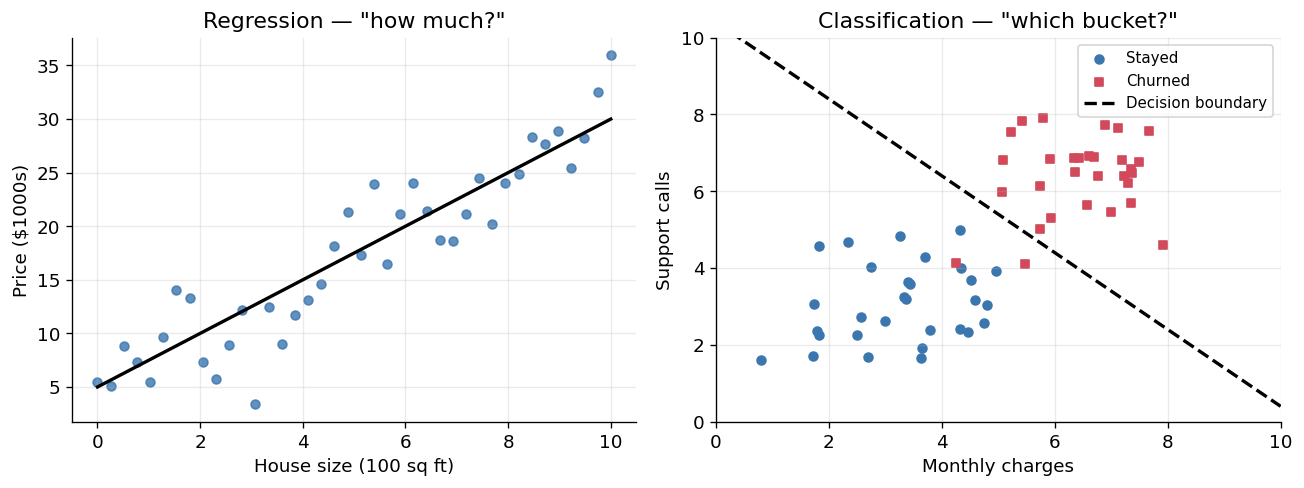

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
rng = np.random.default_rng(0)

# Left: regression — a continuous outcome
x = np.linspace(0, 10, 40); y = 2.5 * x + 5 + rng.normal(0, 4, 40)
ax[0].scatter(x, y, color=C0, s=28, alpha=.8)
ax[0].plot(x, 2.5 * x + 5, color='k', lw=2)
ax[0].set(title='Regression — "how much?"', xlabel='House size (100 sq ft)', ylabel='Price ($1000s)')

# Right: classification — two labelled groups and a boundary
xa = rng.normal(3, 1, 30); ya = rng.normal(3, 1, 30)
xb = rng.normal(6.5, 1, 30); yb = rng.normal(6.5, 1, 30)
ax[1].scatter(xa, ya, color=C0, s=28, label='Stayed')
ax[1].scatter(xb, yb, color=C1, s=28, marker='s', label='Churned')
xx = np.linspace(0, 10, 10)
ax[1].plot(xx, 10.4 - xx, 'k--', lw=2, label='Decision boundary')
ax[1].set(title='Classification — "which bucket?"', xlabel='Monthly charges',
          ylabel='Support calls', xlim=(0, 10), ylim=(0, 10))
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT + "fig01_regression_vs_classification.png")
plt.show()

### Figure 2 — Why linear regression fails at classification  ·  *guide §2*

Both flaws in one diagram: the OLS line predicts values outside [0, 1] (Flaw 1), and three
far-right points tilt the line so the 0.5 cut slides right and misclassifies a point that never
moved (Flaw 2). *Note:* this cell builds its own two-panel figure — earlier the `plt.subplots`
line was missing, which is fixed here.

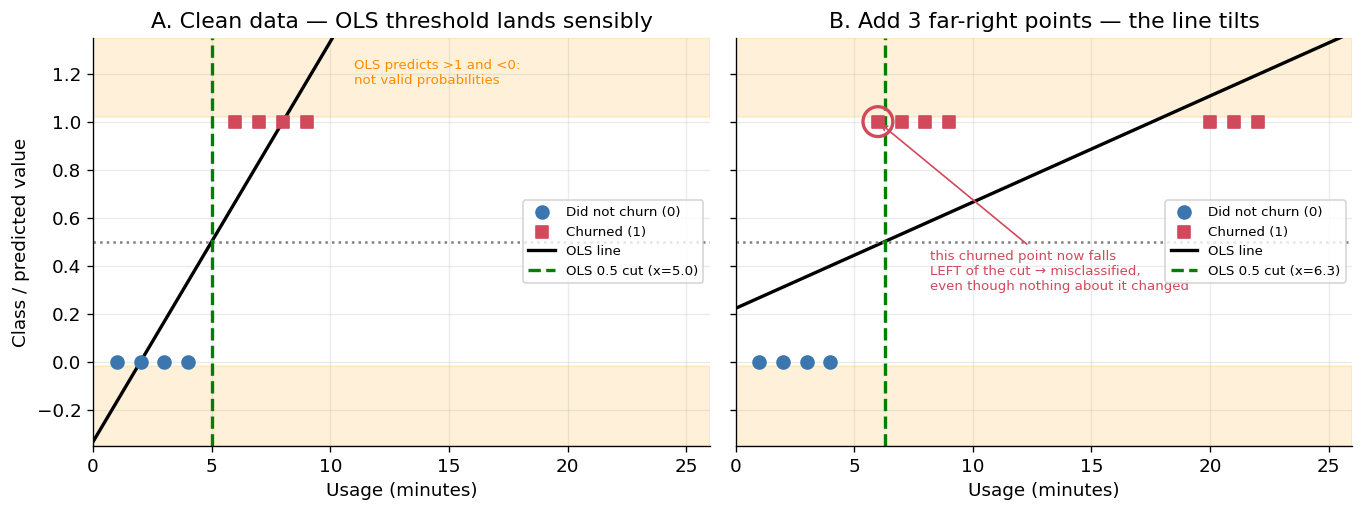

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)

x0 = np.array([1, 2, 3, 4.]); x1 = np.array([6, 7, 8, 9.])
X = np.r_[x0, x1]; Y = np.r_[np.zeros(4), np.ones(4)]
grid = np.linspace(0, 26, 300)

for i, (Xi, Yi, ttl) in enumerate([
        (X, Y, 'A. Clean data — OLS threshold lands sensibly'),
        (np.r_[X, [20, 21, 22.]], np.r_[Y, [1, 1, 1.]], 'B. Add 3 far-right points — the line tilts')]):
    b0, b1 = ols(Xi, Yi); thr = (0.5 - b0) / b1
    ax[i].scatter(Xi[Yi == 0], Yi[Yi == 0], color=C0, s=60, zorder=3, label='Did not churn (0)')
    ax[i].scatter(Xi[Yi == 1], Yi[Yi == 1], color=C1, s=60, marker='s', zorder=3, label='Churned (1)')
    ax[i].plot(grid, b0 + b1 * grid, color='k', lw=2, label='OLS line')
    ax[i].axhline(0.5, ls=':', color='gray')
    ax[i].axvline(thr, ls='--', color='green', lw=2, label=f'OLS 0.5 cut (x={thr:.1f})')
    ax[i].axhspan(1.02, 1.35, color='orange', alpha=.15)
    ax[i].axhspan(-0.35, -0.02, color='orange', alpha=.15)
    ax[i].set(title=ttl, xlabel='Usage (minutes)', ylim=(-0.35, 1.35), xlim=(0, 26))
    ax[i].legend(fontsize=8, loc='center right')

ax[0].set_ylabel('Class / predicted value')
ax[0].text(11, 1.16, 'OLS predicts >1 and <0:\nnot valid probabilities', fontsize=8, color='darkorange')
# With the tilted cut at x=6.3, only the churned point at x=6 is now misclassified
ax[1].scatter([6], [1], facecolor='none', edgecolor=C1, s=320, lw=2, zorder=5)
ax[1].annotate('this churned point now falls\nLEFT of the cut → misclassified,\neven though nothing about it changed',
               xy=(6, 1.0), xytext=(8.2, 0.30), fontsize=8, color=C1,
               arrowprops=dict(arrowstyle='->', color=C1))

plt.tight_layout()
plt.savefig(OUT + "fig02_why_linear_fails.png")
plt.show()

### Figure 3 — The sigmoid function  ·  *guide §3*

The S-curve that turns any real number into a probability in (0, 1), with the three numeric
checks from the text marked on it (σ(−2)≈0.12, σ(0)=0.5, σ(2)≈0.88) and the saturating tails
labelled. *Edit points:* the three marked `(zz, lab)` pairs; the saturation labels.

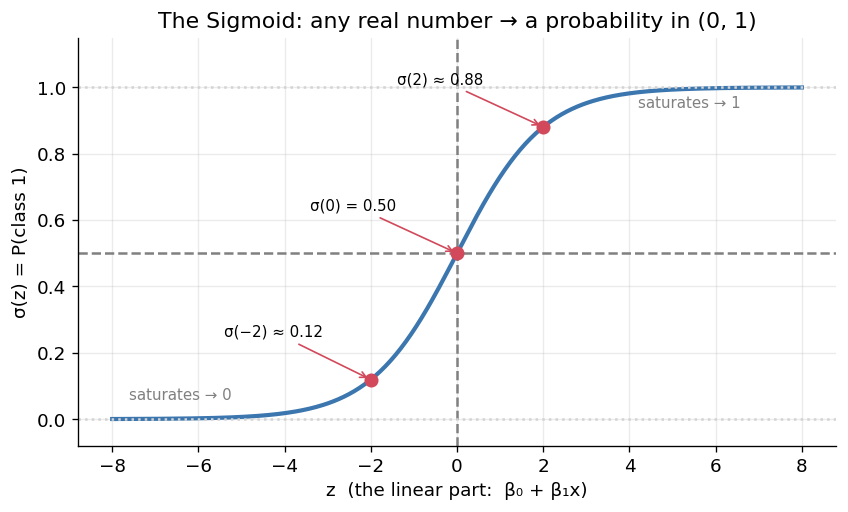

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))

z = np.linspace(-8, 8, 400)
ax.plot(z, sig(z), color=C0, lw=2.5)
ax.axhline(0.5, ls='--', color='gray'); ax.axvline(0, ls='--', color='gray')
ax.axhline(1, ls=':', color='lightgray'); ax.axhline(0, ls=':', color='lightgray')

for zz, lab in [(-2, 'σ(−2) ≈ 0.12'), (0, 'σ(0) = 0.50'), (2, 'σ(2) ≈ 0.88')]:
    ax.scatter([zz], [sig(zz)], color=C1, zorder=4, s=55)
    ax.annotate(lab, xy=(zz, sig(zz)), xytext=(zz - 3.4, sig(zz) + 0.13), fontsize=9,
                arrowprops=dict(arrowstyle='->', color=C1, lw=1))

ax.text(4.2, 0.94, 'saturates → 1', fontsize=9, color='gray')
ax.text(-7.6, 0.06, 'saturates → 0', fontsize=9, color='gray')
ax.set(title='The Sigmoid: any real number → a probability in (0, 1)',
       xlabel='z  (the linear part:  β₀ + β₁x)', ylabel='σ(z) = P(class 1)', ylim=(-0.08, 1.15))

plt.tight_layout()
plt.savefig(OUT + "fig03_sigmoid.png")
plt.show()

### Figure 4 — The spam model as one point in ROC space  ·  *guide §11*

Built from the spam counts introduced in §3.1 (TP=321, TN=58, FP=12, FN=8) and reused in §11 to show that a confusion matrix gives exactly **one** point in ROC space — while the full curve needs scores at many thresholds. *Edit points:* the four counts and the annotation.

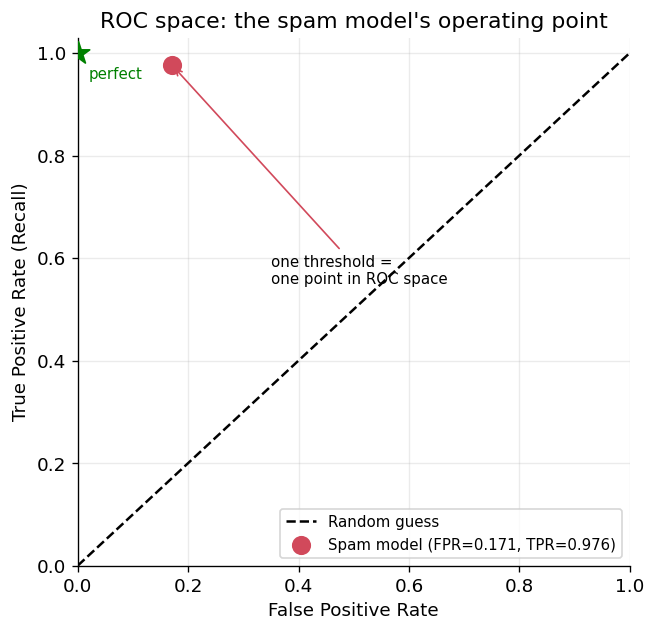

In [5]:
TP, TN, FP, FN = 321, 58, 12, 8
tpr = TP / (TP + FN); fpr = FP / (FP + TN)

fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.scatter([fpr], [tpr], color=C1, s=110, zorder=4,
           label=f'Spam model (FPR={fpr:.3f}, TPR={tpr:.3f})')
ax.annotate('one threshold =\none point in ROC space', xy=(fpr, tpr), xytext=(0.35, 0.55),
            fontsize=9, arrowprops=dict(arrowstyle='->', color=C1))
ax.scatter([0], [1], marker='*', s=200, color='green', zorder=4)
ax.text(0.02, 0.95, 'perfect', color='green', fontsize=9)
ax.set(title="ROC space: the spam model's operating point", xlabel='False Positive Rate',
       ylabel='True Positive Rate (Recall)', xlim=(0, 1), ylim=(0, 1.03))
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(OUT + "fig04_spam_roc_point.png")
plt.show()

### Figure 5 — Probability ↔ odds ↔ log-odds  ·  *guide §4*

The two translations that make logistic regression work, with the churn walk (p=0.20 → 0.335
after a +0.7 coefficient bump) traced on the log-odds curve. *Edit points:* the two annotated
`(pv, lab, col)` points and the arrow.

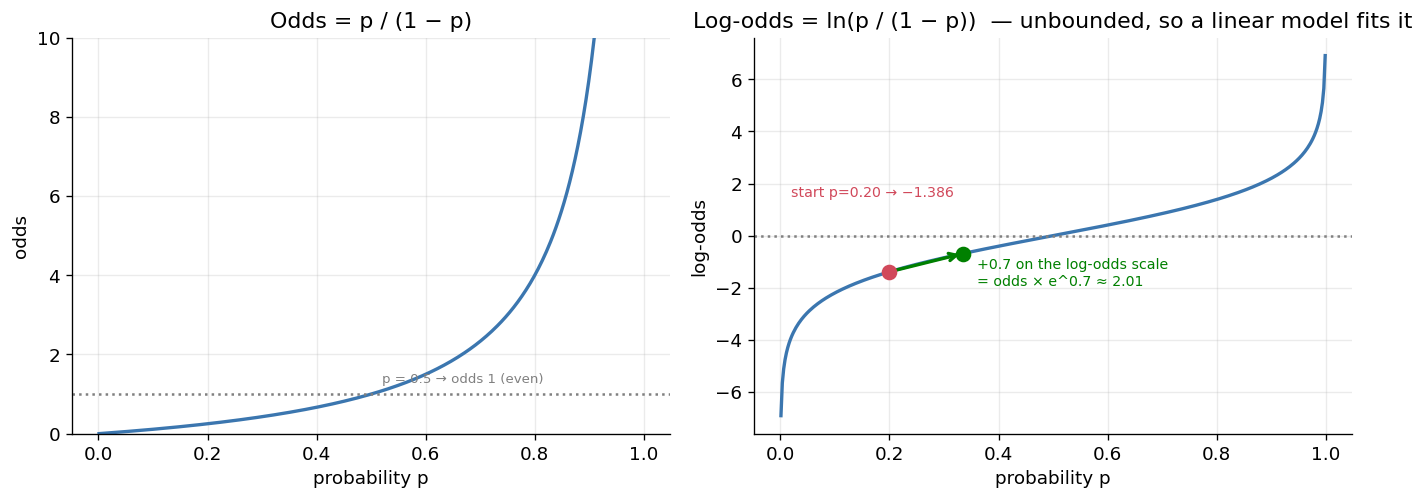

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
p = np.linspace(0.001, 0.999, 400)

ax[0].plot(p, p / (1 - p), color=C0, lw=2)
ax[0].set(title='Odds = p / (1 − p)', xlabel='probability p', ylabel='odds', ylim=(0, 10))
ax[0].axhline(1, ls=':', color='gray')
ax[0].text(0.52, 1.3, 'p = 0.5 → odds 1 (even)', fontsize=8, color='gray')

ax[1].plot(p, np.log(p / (1 - p)), color=C0, lw=2)
ax[1].axhline(0, ls=':', color='gray')
ax[1].set(title='Log-odds = ln(p / (1 − p))  — unbounded, so a linear model fits it',
          xlabel='probability p', ylabel='log-odds')
for pv, lab, col in [(0.20, 'start: p=0.20\nlog-odds=−1.386', C1),
                     (0.335, 'after +1 call (β=0.7)\nlog-odds=−0.686\np=0.335', 'green')]:
    ax[1].scatter([pv], [np.log(pv / (1 - pv))], color=col, s=70, zorder=4)
ax[1].annotate('', xy=(0.335, np.log(0.335 / 0.665)), xytext=(0.20, np.log(0.2 / 0.8)),
               arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax[1].text(0.36, -1.9, '+0.7 on the log-odds scale\n= odds × e^0.7 ≈ 2.01', fontsize=8.5, color='green')
ax[1].text(0.02, 1.5, 'start p=0.20 → −1.386', fontsize=8.5, color=C1)

plt.tight_layout()
plt.savefig(OUT + "fig05_probability_odds_logodds.png")
plt.show()

### Figure 6 — The linear decision boundary with probability shading  ·  *guide §5*

Two features, so the boundary is a straight line; the colour shading shows the smooth
probability gradient, with a pale band of uncertainty straddling the fence. *Edit points:*
the two cluster centres (`Xa`, `Xb`) and the boundary annotation.

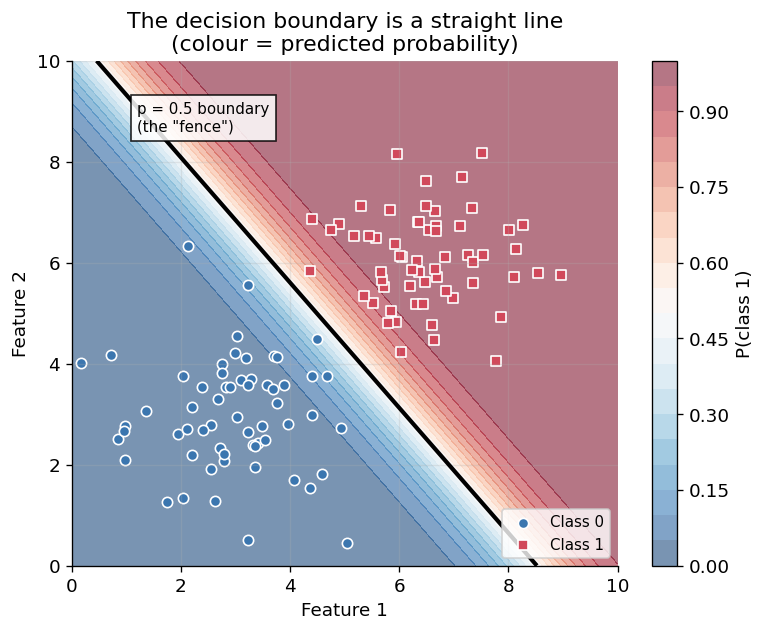

In [7]:
rng = np.random.default_rng(3)

Xa = rng.normal([3, 3], 1.0, (60, 2)); Xb = rng.normal([6.5, 6.0], 1.0, (60, 2))
X = np.vstack([Xa, Xb]); y = np.r_[np.zeros(60), np.ones(60)]
m = LogisticRegression().fit(X, y)

gx, gy = np.meshgrid(np.linspace(0, 10, 300), np.linspace(0, 10, 300))
P = m.predict_proba(np.c_[gx.ravel(), gy.ravel()])[:, 1].reshape(gx.shape)

fig, ax = plt.subplots(figsize=(6.6, 5.4))
cs = ax.contourf(gx, gy, P, levels=20, cmap='RdBu_r', alpha=.55)
plt.colorbar(cs, ax=ax, label='P(class 1)')
ax.contour(gx, gy, P, levels=[0.5], colors='k', linewidths=2.5)
ax.scatter(Xa[:, 0], Xa[:, 1], color=C0, edgecolor='w', s=38, label='Class 0')
ax.scatter(Xb[:, 0], Xb[:, 1], color=C1, edgecolor='w', marker='s', s=38, label='Class 1')
ax.text(1.2, 8.6, 'p = 0.5 boundary\n(the "fence")', fontsize=9,
        bbox=dict(fc='white', alpha=.85, ec='k'))
ax.set(title='The decision boundary is a straight line\n(colour = predicted probability)',
       xlabel='Feature 1', ylabel='Feature 2', xlim=(0, 10), ylim=(0, 10))
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(OUT + "fig06_decision_boundary.png")
plt.show()

### Figure 7 — One-vs-Rest vs. multinomial softmax  ·  *guide §6*

Three classes, two strategies: OvR's three independent "class-k-vs-rest" boundaries (dashed,
left) versus one joint softmax carving the plane into three regions (right). *Edit points:*
the three cluster centres (`cA,cB,cC`) and the class names.

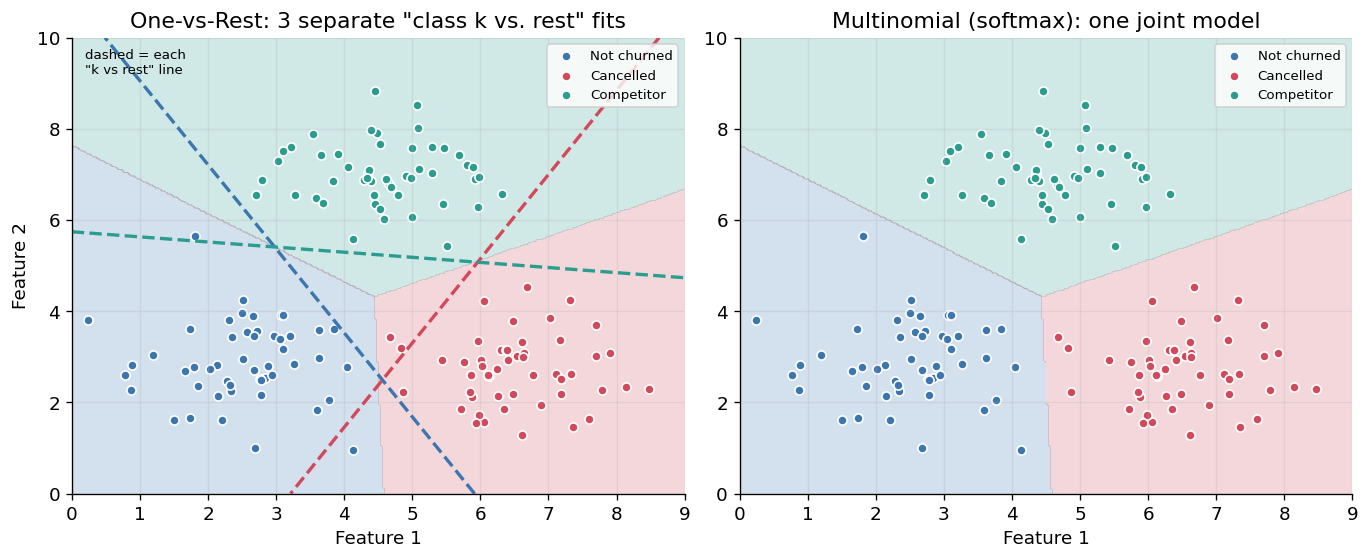

In [8]:
rng = np.random.default_rng(3)

cA = rng.normal([2.5, 3], 0.8, (50, 2))
cB = rng.normal([6.5, 2.5], 0.8, (50, 2))
cC = rng.normal([4.5, 7], 0.8, (50, 2))
X3 = np.vstack([cA, cB, cC]); y3 = np.r_[np.zeros(50), np.ones(50), 2 * np.ones(50)]
gx, gy = np.meshgrid(np.linspace(0, 9, 300), np.linspace(0, 10, 300))
G = np.c_[gx.ravel(), gy.ravel()]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.8))
cols = [C0, C1, '#2a9d8f']
for i, (ttl, est) in enumerate([
        ('One-vs-Rest: 3 separate "class k vs. rest" fits', LogisticRegression().fit(X3, y3)),
        ('Multinomial (softmax): one joint model', LogisticRegression().fit(X3, y3))]):
    Z = est.predict(G).reshape(gx.shape)
    ax[i].contourf(gx, gy, Z, levels=[-.5, .5, 1.5, 2.5], colors=cols, alpha=.22)
    for k, (c, nm) in enumerate(zip(cols, ['Not churned', 'Cancelled', 'Competitor'])):
        ax[i].scatter(X3[y3 == k, 0], X3[y3 == k, 1], color=c, s=30, edgecolor='w', label=nm)
    ax[i].set(title=ttl, xlabel='Feature 1', xlim=(0, 9), ylim=(0, 10))
    ax[i].legend(fontsize=8, loc='upper right')
ax[0].set_ylabel('Feature 2')

# Overlay the three OvR binary boundaries on the left panel
for k, c in enumerate(cols):
    yb = (y3 == k).astype(int)
    mb = LogisticRegression().fit(X3, yb)
    Zb = mb.predict_proba(G)[:, 1].reshape(gx.shape)
    ax[0].contour(gx, gy, Zb, levels=[0.5], colors=[c], linewidths=2, linestyles='--')
ax[0].text(0.2, 9.2, 'dashed = each\n"k vs rest" line', fontsize=8)

plt.tight_layout()
plt.savefig(OUT + "fig07_multiclass_ovr_softmax.png")
plt.show()

### Figure 8 — L1 vs. L2 regularization paths  ·  *guide §8*

Each line is one feature's coefficient as `C` sweeps from strong penalty (left) to weak (right).
L1 pins noise features at *exactly* zero; L2 shrinks them but never to zero. *Edit points:*
the `true` coefficient vector (which features are signal vs. noise) and the two annotations.

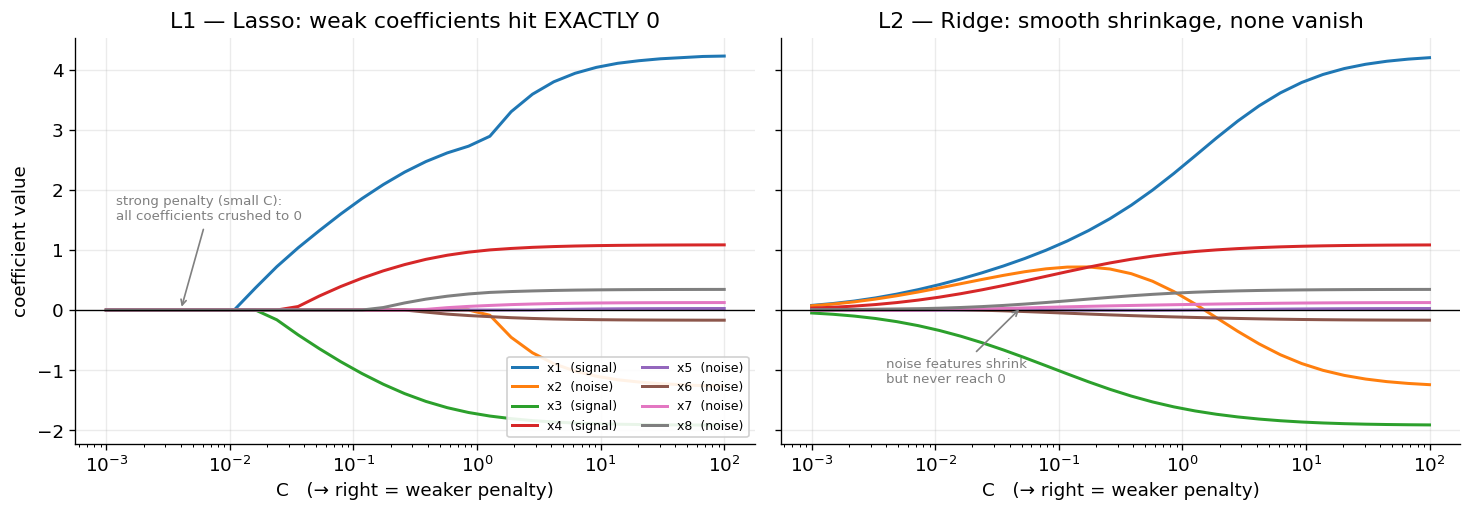

In [9]:
rng = np.random.default_rng(3); n = 300

Xr = rng.normal(0, 1, (n, 8))
Xr[:, 1] = Xr[:, 0] * 0.95 + rng.normal(0, 0.2, n)   # make x2 correlated with x1
true = np.array([2.5, 0, -2.0, 1.2, 0, 0, 0, 0])     # 4 signal features, 4 noise
yr = (rng.random(n) < 1 / (1 + np.exp(-(Xr @ true)))).astype(int)
Cs = np.logspace(-3, 2, 30)

fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.4), sharey=True)
for i, pen in enumerate(['l1', 'l2']):
    paths = np.array([LogisticRegression(penalty=pen, C=c, solver='liblinear', max_iter=2000)
                      .fit(Xr, yr).coef_[0] for c in Cs])
    for j in range(8):
        lbl = f'x{j+1}  {"(signal)" if true[j] != 0 else "(noise)"}' if i == 0 else None
        ax[i].plot(Cs, paths[:, j], lw=1.8, label=lbl)
    ax[i].set_xscale('log'); ax[i].axhline(0, color='k', lw=.8)
    title = "Lasso: weak coefficients hit EXACTLY 0" if pen == 'l1' else "Ridge: smooth shrinkage, none vanish"
    ax[i].set(title=f'{pen.upper()} — {title}', xlabel='C   (→ right = weaker penalty)')
ax[0].set_ylabel('coefficient value')
ax[0].annotate('strong penalty (small C):\nall coefficients crushed to 0', xy=(0.004, 0),
               xytext=(0.0012, 1.5), fontsize=8, color='gray', arrowprops=dict(arrowstyle='->', color='gray'))
ax[1].annotate('noise features shrink\nbut never reach 0', xy=(0.05, 0.05), xytext=(0.004, -1.2),
               fontsize=8, color='gray', arrowprops=dict(arrowstyle='->', color='gray'))
ax[0].legend(fontsize=7.5, ncol=2, loc='lower right', framealpha=.9)

plt.tight_layout()
plt.savefig(OUT + "fig08_regularization_paths.png")
plt.show()

### Figure 9 — The confusion matrix (mini worked example)  ·  *guide §9*

The 100-case example (TP=18, FN=2, FP=10, TN=70) laid out as a 2×2 grid, showing how one table
yields accuracy 0.88, recall 0.90, precision 0.64. *Edit points:* the `cm` counts and the four
cell labels.

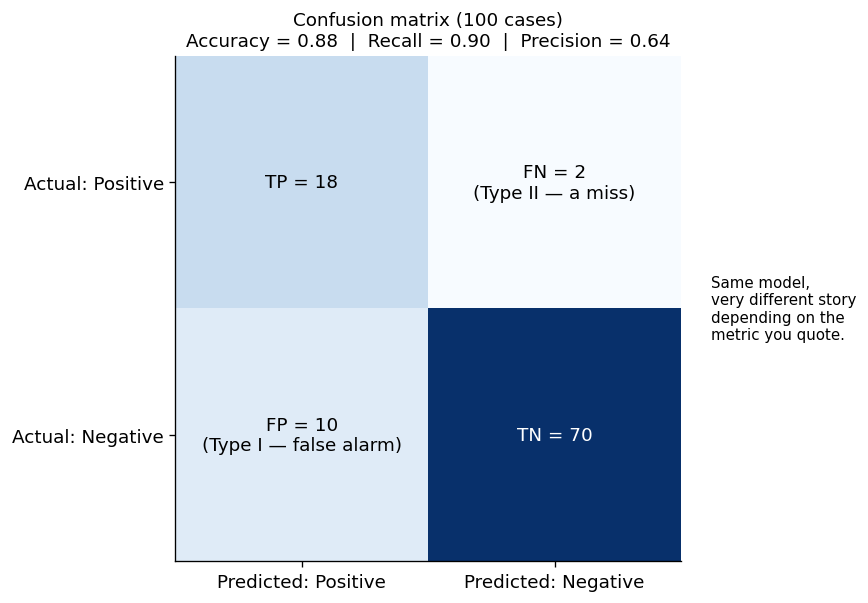

In [10]:
cm = np.array([[18, 2], [10, 70]])

fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.imshow(cm, cmap='Blues')
lab = [['TP = 18', 'FN = 2\n(Type II — a miss)'],
       ['FP = 10\n(Type I — false alarm)', 'TN = 70']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, lab[i][j], ha='center', va='center', fontsize=11,
                color='white' if cm[i, j] > 40 else 'black')
ax.set_xticks([0, 1], ['Predicted: Positive', 'Predicted: Negative'])
ax.set_yticks([0, 1], ['Actual: Positive', 'Actual: Negative'])
ax.set_title('Confusion matrix (100 cases)\nAccuracy = 0.88  |  Recall = 0.90  |  Precision = 0.64', fontsize=11)
ax.grid(False)
ax.text(1.62, 0.5, 'Same model,\nvery different story\ndepending on the\nmetric you quote.', fontsize=9, va='center')

plt.tight_layout()
plt.savefig(OUT + "fig09_confusion_matrix.png")
plt.show()

### Figure 10 — Precision & recall vs. the threshold  ·  *guide §10*

Sweeping the decision threshold trades recall against precision; F1 peaks in between. Shows the
threshold is a dial you control, not a fixed 0.5. *Edit points:* the two annotations and the
class balance (`0.3`).

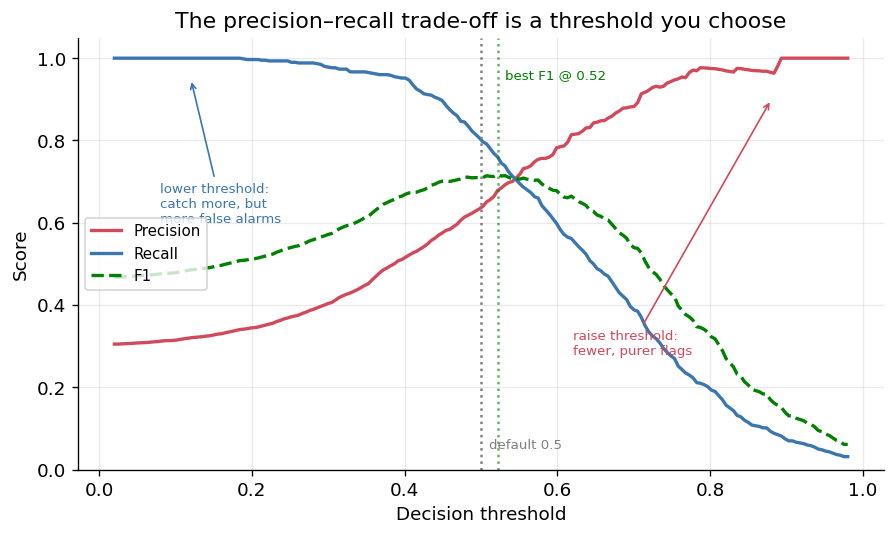

In [11]:
rng = np.random.default_rng(7)
n = 2000
y = (rng.random(n) < 0.3).astype(int)
s = np.clip(rng.normal(np.where(y == 1, 0.65, 0.35), 0.17), 0, 1)

th = np.linspace(0.02, 0.98, 200); P = []; R = []; F = []
for t in th:
    pred = (s >= t).astype(int)
    tp = ((pred == 1) & (y == 1)).sum(); fp = ((pred == 1) & (y == 0)).sum(); fn = ((pred == 0) & (y == 1)).sum()
    pr = tp / (tp + fp) if tp + fp else 1.0
    rc = tp / (tp + fn) if tp + fn else 0.0
    P.append(pr); R.append(rc); F.append(2 * pr * rc / (pr + rc) if pr + rc else 0)

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.plot(th, P, color=C1, lw=2, label='Precision')
ax.plot(th, R, color=C0, lw=2, label='Recall')
ax.plot(th, F, color='green', lw=2, ls='--', label='F1')
ax.axvline(0.5, color='gray', ls=':'); ax.text(0.51, 0.05, 'default 0.5', fontsize=8, color='gray')
best = th[int(np.argmax(F))]; ax.axvline(best, color='green', ls=':', alpha=.6)
ax.text(best + 0.01, 0.95, f'best F1 @ {best:.2f}', fontsize=8, color='green')
ax.annotate('lower threshold:\ncatch more, but\nmore false alarms', xy=(0.12, 0.95), xytext=(0.08, 0.6),
            fontsize=8, color=C0, arrowprops=dict(arrowstyle='->', color=C0))
ax.annotate('raise threshold:\nfewer, purer flags', xy=(0.88, 0.9), xytext=(0.62, 0.28),
            fontsize=8, color=C1, arrowprops=dict(arrowstyle='->', color=C1))
ax.set(title='The precision–recall trade-off is a threshold you choose',
       xlabel='Decision threshold', ylabel='Score', ylim=(0, 1.05))
ax.legend(fontsize=9, loc='center left')

plt.tight_layout()
plt.savefig(OUT + "fig10_precision_recall_threshold.png")
plt.show()

### Figure 11 — What different AUC values look like  ·  *guide §11*

Left: four ROC curves from random (0.5) to perfect (1.0). Right: the same idea as score
histograms — AUC is really about how much the positive and negative score distributions overlap.
*Edit points:* the four `(sep, colour, name)` rows.

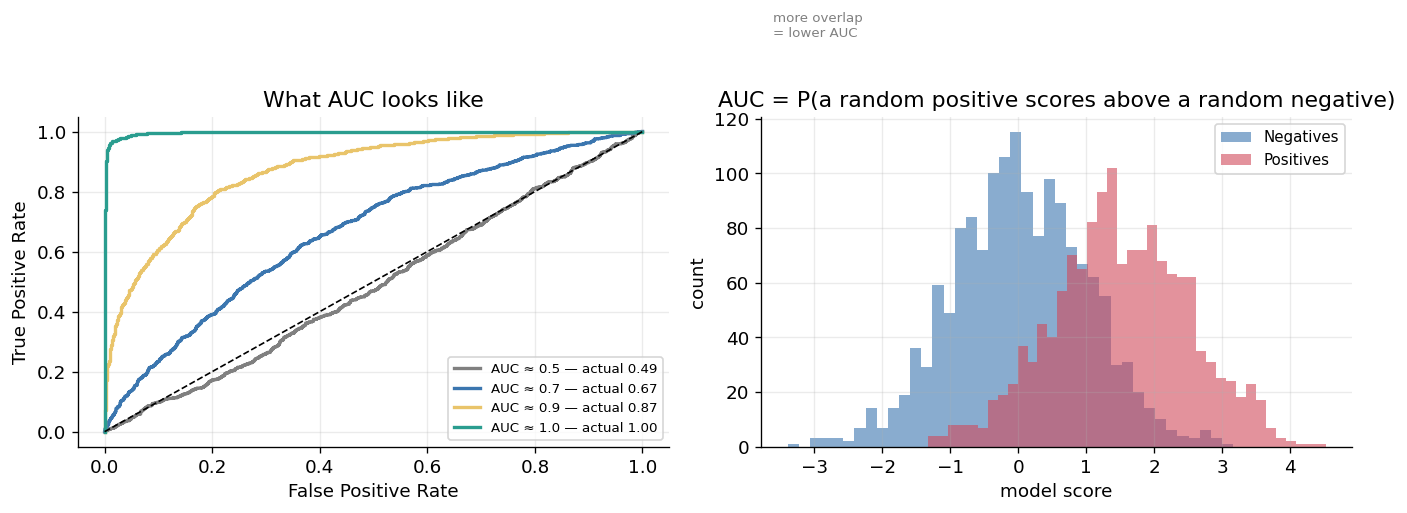

In [12]:
rng = np.random.default_rng(7)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.6))
for sep, c, nm in [(0.0, 'gray', 'AUC ≈ 0.5 (random)'), (0.6, C0, 'AUC ≈ 0.7'),
                   (1.5, '#e9c46a', 'AUC ≈ 0.9'), (4.0, '#2a9d8f', 'AUC ≈ 1.0 (perfect)')]:
    yy = (rng.random(3000) < 0.5).astype(int); ss = rng.normal(yy * sep, 1)
    f, t, _ = roc_curve(yy, ss); a = roc_auc_score(yy, ss)
    ax[0].plot(f, t, color=c, lw=2, label=f'{nm.split("(")[0].strip()} — actual {a:.2f}')
ax[0].plot([0, 1], [0, 1], 'k--', lw=1)
ax[0].set(title='What AUC looks like', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax[0].legend(fontsize=8, loc='lower right')

# Score distributions for the AUC ≈ 0.9 case
yy = (rng.random(3000) < 0.5).astype(int); ss = rng.normal(yy * 1.5, 1)
ax[1].hist(ss[yy == 0], bins=40, alpha=.6, color=C0, label='Negatives')
ax[1].hist(ss[yy == 1], bins=40, alpha=.6, color=C1, label='Positives')
ax[1].set(title='AUC = P(a random positive scores above a random negative)',
          xlabel='model score', ylabel='count')
ax[1].legend(fontsize=9)
ax[1].text(-3.6, 150, 'more overlap\n= lower AUC', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(OUT + "fig11_roc_auc_comparison.png")
plt.show()

### Figure 12 — ROC vs. PR on imbalanced data  ·  *guide §11*

The most important plot in the metrics sections: the **same model on the same 1%-positive data**
scores a flattering ROC-AUC but an honest, much lower average precision. *Note:* this cell uses
`default_rng(5)`, which yields AUC ≈ 0.94 and AP ≈ 0.36 — the numbers quoted in the guide caption.
If you change the seed, update that caption to match.

AUC = 0.942   Average precision = 0.361   positives = 49


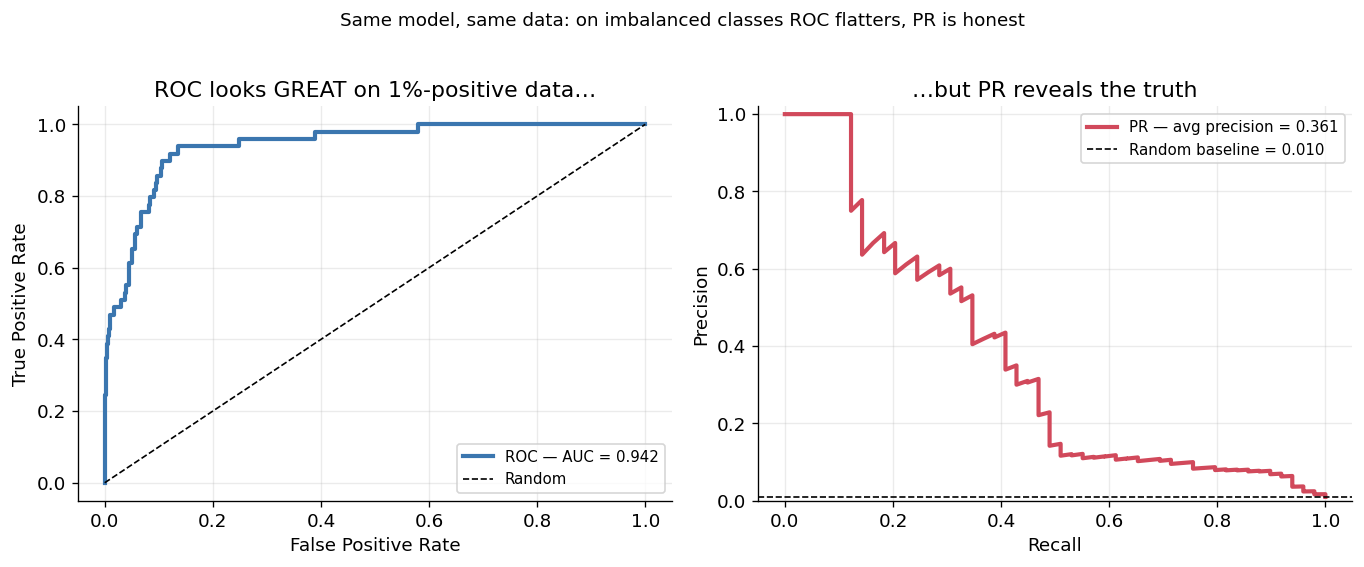

In [13]:
rng = np.random.default_rng(5)

n = 5000
y = (rng.random(n) < 0.01).astype(int)                          # only ~1% positives
s = np.clip(rng.normal(np.where(y == 1, 0.72, 0.35), 0.16), 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.6))
f, t, _ = roc_curve(y, s)
ax[0].plot(f, t, color=C0, lw=2.5, label=f'ROC — AUC = {roc_auc_score(y, s):.3f}')
ax[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax[0].set(title='ROC looks GREAT on 1%-positive data…', xlabel='False Positive Rate',
          ylabel='True Positive Rate')
ax[0].legend(fontsize=9, loc='lower right')

pr, rc, _ = precision_recall_curve(y, s); ap = average_precision_score(y, s)
ax[1].plot(rc, pr, color=C1, lw=2.5, label=f'PR — avg precision = {ap:.3f}')
ax[1].axhline(y.mean(), ls='--', color='k', lw=1, label=f'Random baseline = {y.mean():.3f}')
ax[1].set(title='…but PR reveals the truth', xlabel='Recall', ylabel='Precision', ylim=(0, 1.02))
ax[1].legend(fontsize=9, loc='upper right')
fig.suptitle('Same model, same data: on imbalanced classes ROC flatters, PR is honest', fontsize=11, y=1.02)

# Print the exact numbers so you can sync the guide caption if you change the seed
print(f"AUC = {roc_auc_score(y, s):.3f}   Average precision = {ap:.3f}   positives = {y.sum()}")

plt.tight_layout()
plt.savefig(OUT + "fig12_roc_vs_pr_imbalanced.png")
plt.show()

### Figure 13 — The cost-optimal threshold  ·  *guide §16 (Practical decision guide)*

Total cost of a real classifier as the threshold sweeps 0→1, under three cost ratios. The
measured minima (dots) land on the theoretical t* = C_FP/(C_FP+C_FN) (dashed): 0.05 for cancer,
0.50 for equal costs, 0.95 for spam. *Edit points:* the three `(cfp, cfn, colour, name)` rows.

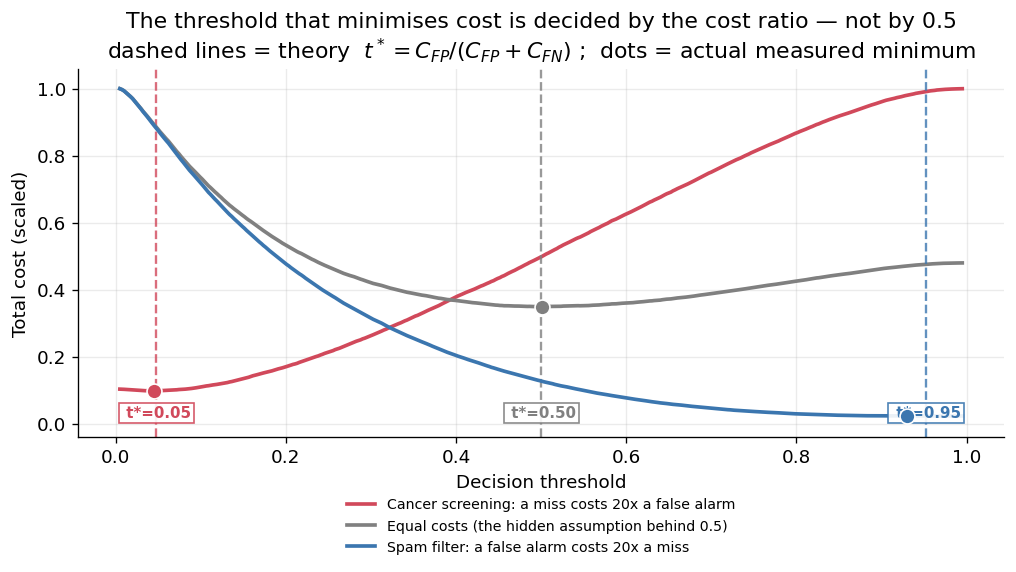

In [14]:
rng = np.random.default_rng(11)

# A realistic, well-calibrated classifier on synthetic data
n = 200000
x = rng.normal(0, 1, (n, 2)); lin = 1.2 * x[:, 0] - 0.8 * x[:, 1] - 1.0
p = 1 / (1 + np.exp(-lin)); y = (rng.random(n) < p).astype(int)
m = LogisticRegression().fit(x[:100000], y[:100000])
s = m.predict_proba(x[100000:])[:, 1]; yt = y[100000:]

th = np.linspace(0.005, 0.995, 400)
fig, ax = plt.subplots(figsize=(8.6, 5.0))
for cfp, cfn, col, nm in [(1, 20, C1, 'Cancer screening: a miss costs 20x a false alarm'),
                          (1, 1, 'gray', 'Equal costs (the hidden assumption behind 0.5)'),
                          (20, 1, C0, 'Spam filter: a false alarm costs 20x a miss')]:
    cost = np.array([cfp * ((s >= t) & (yt == 0)).sum() + cfn * ((s < t) & (yt == 1)).sum()
                     for t in th], float)
    cost /= cost.max()
    ax.plot(th, cost, color=col, lw=2.2, label=nm)
    t_star = cfp / (cfp + cfn)
    ax.axvline(t_star, color=col, ls='--', lw=1.4, alpha=.8)
    ax.scatter([th[cost.argmin()]], [cost.min()], color=col, s=80, zorder=5, edgecolor='w')
    ax.text(t_star, 0.02, f' t*={t_star:.2f}', color=col, fontsize=9, ha='center', weight='bold',
            bbox=dict(fc='white', ec=col, alpha=.9, pad=1.5))
ax.set(title='The threshold that minimises cost is decided by the cost ratio — not by 0.5\n'
             r'dashed lines = theory  $t^*=C_{FP}/(C_{FP}+C_{FN})$ ;  dots = actual measured minimum',
       xlabel='Decision threshold', ylabel='Total cost (scaled)', ylim=(-0.04, 1.06))
ax.legend(fontsize=8.5, loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=1, frameon=False)

plt.tight_layout()
plt.savefig(OUT + "fig13_cost_optimal_threshold.png")
plt.show()

### Figure 14 — The scenario map  ·  *guide §16 (Practical decision guide)*

A 2-axis map (cost of a false positive × cost of a false negative) placing eight real problems
into four quadrants, each labelled with the metric it implies. *Edit points:* the `hdr` quadrant
labels and the `scen` list of problems + positions.

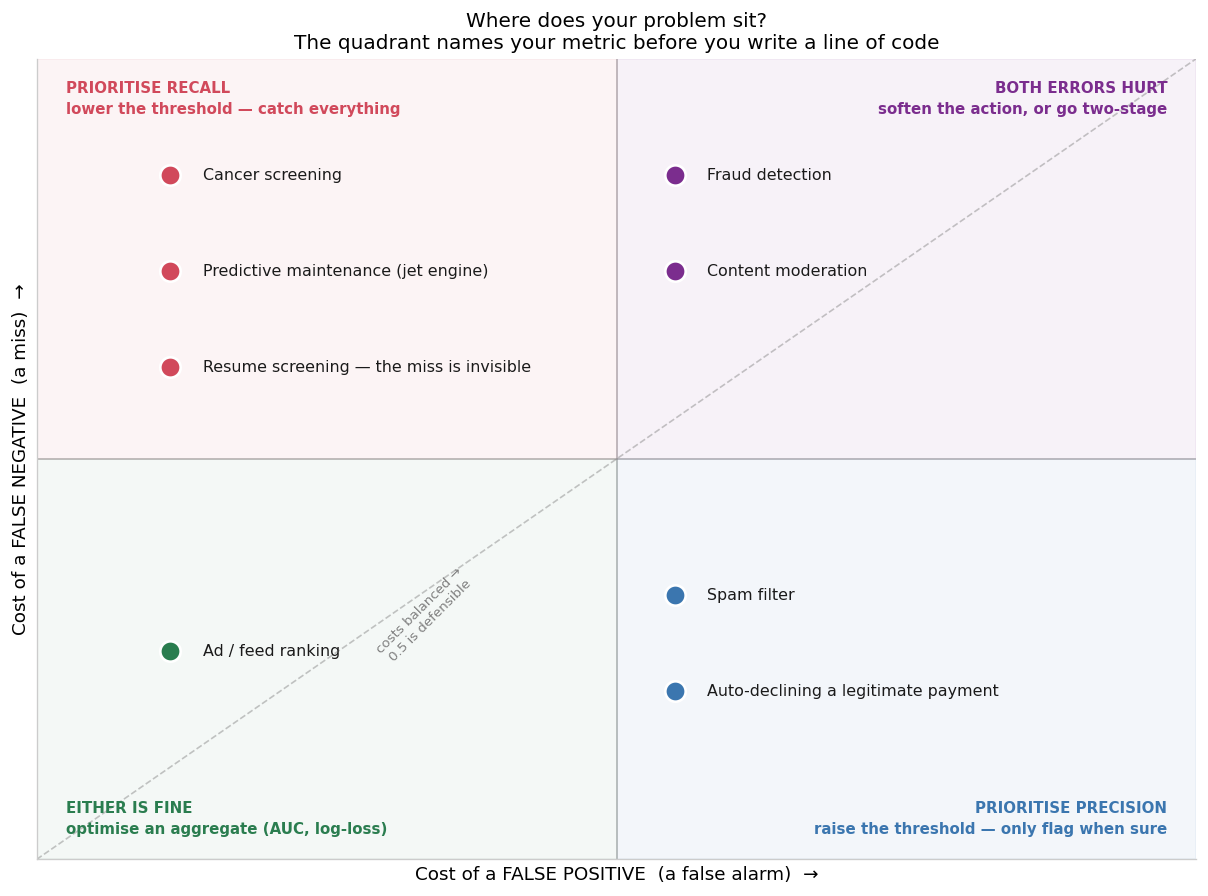

In [15]:
fig, ax = plt.subplots(figsize=(10.2, 7.6))

# Quadrant tints
ax.add_patch(plt.Rectangle((0, 5), 5, 5, color=RED, alpha=.06, zorder=0))
ax.add_patch(plt.Rectangle((5, 5), 5, 5, color=PUR, alpha=.06, zorder=0))
ax.add_patch(plt.Rectangle((5, 0), 5, 5, color=BLUE, alpha=.06, zorder=0))
ax.add_patch(plt.Rectangle((0, 0), 5, 5, color=GRN, alpha=.05, zorder=0))
ax.axhline(5, color='gray', lw=1, alpha=.5); ax.axvline(5, color='gray', lw=1, alpha=.5)
ax.plot([0, 10], [0, 10], '--', color='gray', lw=1, alpha=.45, zorder=1)

# Quadrant headers, parked in the corners away from the dots
hdr = [(0.25, 9.72, 'left', RED, 'PRIORITISE RECALL\nlower the threshold — catch everything'),
       (9.75, 9.72, 'right', PUR, 'BOTH ERRORS HURT\nsoften the action, or go two-stage'),
       (9.75, 0.28, 'right', BLUE, 'PRIORITISE PRECISION\nraise the threshold — only flag when sure'),
       (0.25, 0.28, 'left', GRN, 'EITHER IS FINE\noptimise an aggregate (AUC, log-loss)')]
for X, Y, ha, col, t in hdr:
    ax.text(X, Y, t, fontsize=9, color=col, ha=ha, va='top' if Y > 5 else 'bottom',
            weight='bold', linespacing=1.5)

# The individual problems
scen = [(1.15, 8.55, 'Cancer screening', RED),
        (1.15, 7.35, 'Predictive maintenance (jet engine)', RED),
        (1.15, 6.15, 'Resume screening — the miss is invisible', RED),
        (5.5, 8.55, 'Fraud detection', PUR),
        (5.5, 7.35, 'Content moderation', PUR),
        (5.5, 3.30, 'Spam filter', BLUE),
        (5.5, 2.10, 'Auto-declining a legitimate payment', BLUE),
        (1.15, 2.60, 'Ad / feed ranking', GRN)]
for X, Y, nm, col in scen:
    ax.scatter([X], [Y], s=150, color=col, edgecolor='w', lw=1.6, zorder=5)
    ax.text(X + 0.28, Y, nm, fontsize=9.5, color='#1a1a1a', ha='left', va='center', zorder=5)

ax.text(3.35, 3.05, 'costs balanced →\n0.5 is defensible', rotation=45, fontsize=8, color='gray',
        ha='center', va='center', rotation_mode='anchor')
ax.set(xlim=(0, 10), ylim=(0, 10))
ax.set_xlabel('Cost of a FALSE POSITIVE  (a false alarm)  →', fontsize=11)
ax.set_ylabel('Cost of a FALSE NEGATIVE  (a miss)  →', fontsize=11)
ax.set_title('Where does your problem sit?\nThe quadrant names your metric before you write a line of code', fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_edgecolor('#cccccc')

plt.tight_layout()
plt.savefig(OUT + "fig14_scenario_map.png")
plt.show()